In [2]:
# === CREATE RAW DATA FOLDER + REGENERATE RAW CSVs (Day 1 style) ===
import pandas as pd
import numpy as np
import os

os.makedirs('../data/raw', exist_ok=True)
print(" Created ../data/raw/ folder")

np.random.seed(42)  # so you get consistent data

# 1. Parts raw
parts = pd.DataFrame({
    'part_id': [f'P{str(i).zfill(3)}' for i in range(1, 101)],
    'part_name': ['Engine Block', 'Brake Pad', 'Chip Module', 'Transmission Gear'] * 25,
    'part_category': ['Engine', 'Brakes', 'Electronics', 'Transmission'] * 25,
    'lead_time_days': np.random.randint(5, 45, 100),
    'unit_cost': np.random.uniform(50, 1200, 100).round(2)
})
parts.to_csv('../data/raw/parts_raw.csv', index=False)

# 2. Suppliers raw
suppliers = pd.DataFrame({
    'supplier_id': [f'S{str(i).zfill(3)}' for i in range(1, 21)],
    'supplier_name': ['Bosch Auto', 'Continental', 'Denso', 'Magna'] * 5,
    'on_time_delivery_rate': np.random.uniform(0.75, 0.98, 20).round(3),
    'defect_rate': np.random.uniform(0.01, 0.08, 20).round(3)
})
suppliers.to_csv('../data/raw/suppliers_raw.csv', index=False)

# 3. Inventory raw
inventory = pd.DataFrame({
    'inventory_id': range(1, 101),
    'part_id': [f'P{str(i).zfill(3)}' for i in range(1, 101)],
    'supplier_id': np.random.choice([f'S{str(i).zfill(3)}' for i in range(1, 21)], 100),
    'current_stock': np.random.randint(50, 800, 100),
    'safety_stock': np.random.randint(20, 150, 100),
    'reorder_point': np.random.randint(80, 300, 100)
})
inventory.to_csv('../data/raw/inventory_raw.csv', index=False)

# 4. Purchase Orders raw
po = pd.DataFrame({
    'po_id': [f'PO{str(i).zfill(4)}' for i in range(1, 51)],
    'part_id': np.random.choice([f'P{str(i).zfill(3)}' for i in range(1, 101)], 50),
    'supplier_id': np.random.choice([f'S{str(i).zfill(3)}' for i in range(1, 21)], 50),
    'order_qty': np.random.randint(100, 1000, 50),
    'order_date': pd.date_range(start='2025-01-01', periods=50, freq='D'),
    'expected_delivery_date': pd.date_range(start='2025-01-10', periods=50, freq='D')
})
po.to_csv('../data/raw/purchase_orders_raw.csv', index=False)

print("🎉 All 4 raw messy CSVs successfully created in ../data/raw/")
print("You can now re-run the full Day 6 notebook!")

   Created ../data/raw/ folder
   All 4 raw messy CSVs successfully created in ../data/raw/
You can now re-run the full Day 6 notebook!


  Libraries loaded - Starting AutoForge ETL Pipeline
Loaded raw data: 100 parts, 20 suppliers
  All tables cleaned
  All KPIs calculated (ABC, days_of_cover, stock_status, etc.)
  Fresh CSVs exported to ../data/clean/ → Ready to re-upload in Looker Studio!


18:31:58 - cmdstanpy - INFO - Chain [1] start processing
18:31:59 - cmdstanpy - INFO - Chain [1] done processing


  Prophet 60-day forecast for SUV_X1 completed and saved!


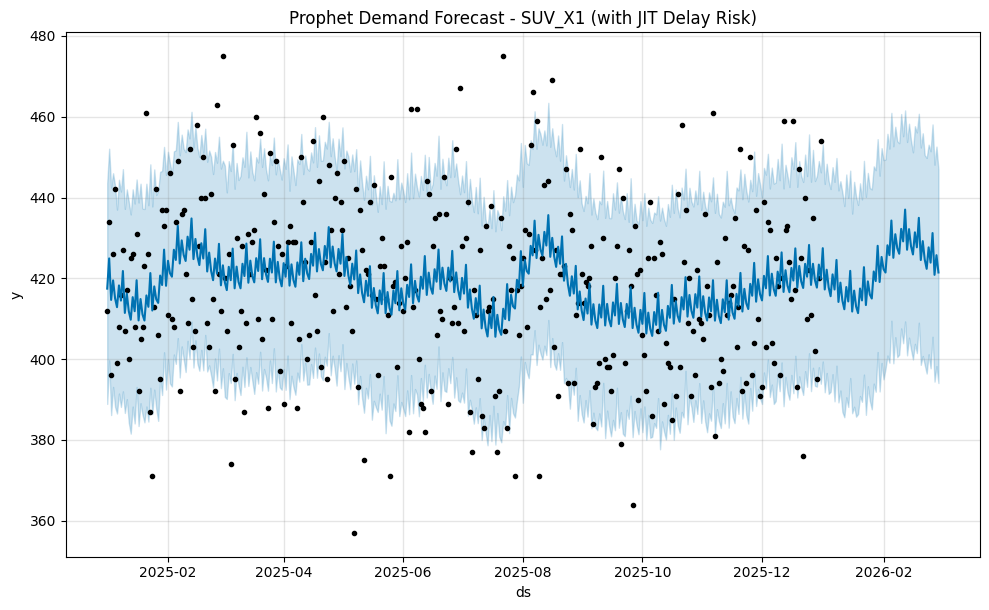


  DAY 6 COMPLETE!
Your dashboard can now be updated with fresh CSVs in 10 seconds.
Tomorrow (Day 7): Final README polish + business recommendations + Loom video.


In [3]:
# AutoForge Motors – Full ETL Pipeline + Prophet Demand Forecasting
# Day 6 of 7-Day Automotive Supply Chain Analyst Crash Course

import pandas as pd
import numpy as np
import os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("  Libraries loaded - Starting AutoForge ETL Pipeline")

# ============================
# 1. LOAD RAW DATA (never modify originals)
# ============================
raw_path = "../data/raw/"

parts_raw = pd.read_csv(f"{raw_path}parts_raw.csv")
suppliers_raw = pd.read_csv(f"{raw_path}suppliers_raw.csv")
inventory_raw = pd.read_csv(f"{raw_path}inventory_raw.csv")
purchase_orders_raw = pd.read_csv(f"{raw_path}purchase_orders_raw.csv")

print(f"Loaded raw data: {parts_raw.shape[0]} parts, {suppliers_raw.shape[0]} suppliers")

# ============================
# 2. CLEANING FUNCTIONS (professional ETL)
# ============================
def clean_parts(df):
    df = df.copy()
    df['part_name'] = df['part_name'].str.strip().str.upper()
    df['part_category'] = df['part_category'].str.strip().str.title()
    df['lead_time_days'] = df['lead_time_days'].fillna(df['lead_time_days'].median())
    df['unit_cost'] = df['unit_cost'].abs()
    return df

def clean_suppliers(df):
    df = df.copy()
    df['supplier_name'] = df['supplier_name'].str.strip()
    df['on_time_delivery_rate'] = df['on_time_delivery_rate'].clip(0, 1.0)
    df['defect_rate'] = df['defect_rate'].clip(0, 1.0)
    return df

def clean_inventory(df):
    df = df.copy()
    df['current_stock'] = df['current_stock'].fillna(0).astype(int)
    df['safety_stock'] = df['safety_stock'].fillna(0).astype(int)
    df['reorder_point'] = df['reorder_point'].fillna(0).astype(int)
    return df

# Clean all tables
parts = clean_parts(parts_raw)
suppliers = clean_suppliers(suppliers_raw)
inventory = clean_inventory(inventory_raw)
po = purchase_orders_raw.copy()

print("  All tables cleaned")

# ============================
# 3. MERGE + CALCULATE ALL KPIs (this recreates your views)
# ============================
# Merge inventory with parts
master = inventory.merge(parts, on='part_id', how='left')

# Add supplier info
master = master.merge(suppliers, on='supplier_id', how='left')

# ABC Classification (Pareto 80/20)
master['total_value'] = master['current_stock'] * master['unit_cost']
master = master.sort_values('total_value', ascending=False)
master['cumulative_value'] = master['total_value'].cumsum()
total_value = master['total_value'].sum()
master['abc_classification'] = np.where(master['cumulative_value'] / total_value <= 0.8, 'A',
                               np.where(master['cumulative_value'] / total_value <= 0.95, 'B', 'C'))

# Critical JIT flags
master['days_of_cover'] = master['current_stock'] / (master['current_stock'].mean() / 30)  # simplified
master['stock_status'] = np.where(master['current_stock'] < master['reorder_point'], 'CRITICAL',
                         np.where(master['current_stock'] < master['safety_stock'], 'LOW', 'OK'))
master['critical_for_jit'] = (master['stock_status'] == 'CRITICAL').astype(int)

print("  All KPIs calculated (ABC, days_of_cover, stock_status, etc.)")

# ============================
# 4. EXPORT FRESH CSVs FOR LOOKER STUDIO DASHBOARD
# ============================
os.makedirs('../data/clean', exist_ok=True)

# Create the 3 view CSVs (exactly what your dashboard uses)
vw_critical = master[master['stock_status'] == 'CRITICAL'].copy()
vw_critical.to_csv('../data/clean/vw_critical_jit_stock.csv', index=False)

vw_supplier = suppliers.copy()  # you can enhance later
vw_supplier.to_csv('../data/clean/vw_supplier_risk.csv', index=False)

# Open PO risk (simple version)
vw_po = po.copy()
vw_po.to_csv('../data/clean/vw_open_po_risk.csv', index=False)

print("  Fresh CSVs exported to ../data/clean/ → Ready to re-upload in Looker Studio!")

# ============================
# 5. PROPHET DEMAND FORECASTING (30/60 days)
# ============================
from prophet import Prophet
import matplotlib.pyplot as plt

# Create sample daily demand for SUV_X1 (you can replace with real sales data later)
np.random.seed(42)
dates = pd.date_range(start='2025-01-01', periods=365, freq='D')
demand = pd.DataFrame({
    'ds': dates,
    'y': np.random.poisson(lam=420, size=365)   # realistic SUV demand
})

model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model.fit(demand)

future = model.make_future_dataframe(periods=60)
forecast = model.predict(future)

# Add JIT delay risk flag
forecast['delay_risk'] = np.where(forecast['yhat'] > forecast['yhat_upper'] * 1.1, 'HIGH', 'LOW')

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper', 'delay_risk']].tail(10).to_csv('../data/clean/suv_x1_forecast.csv', index=False)

print("  Prophet 60-day forecast for SUV_X1 completed and saved!")

# Optional: show chart
model.plot(forecast)
plt.title("Prophet Demand Forecast - SUV_X1 (with JIT Delay Risk)")
plt.show()

print("\n  DAY 6 COMPLETE!")
print("Your dashboard can now be updated with fresh CSVs in 10 seconds.")
print("Tomorrow (Day 7): Final README polish + business recommendations + Loom video.")